## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\results\04_model")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("✅ Imports done")
print(f"✅ Results folder: {RESULTS_PATH}")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available : {torch.cuda.is_available()}")
print(f"✅ GPU            : {torch.cuda.get_device_name(0)}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    a

✅ Imports done
✅ Results folder: C:\Users\Admin\Desktop\madhura\nnunet_project\results\04_model
✅ PyTorch version: 2.1.2+cu121
✅ CUDA available : True
✅ GPU            : NVIDIA GeForce RTX 4060


## Double Conv Block

In [2]:
class DoubleConv3D(nn.Module):
    """
    Basic building block of U-Net:
    Conv3D → InstanceNorm → LeakyReLU → Conv3D → InstanceNorm → LeakyReLU
    nnU-Net uses InstanceNorm (not BatchNorm) for small batch sizes
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, 
                      kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),

            nn.Conv3d(out_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# ── Quick test ─────────────────────────────────────────────
x    = torch.randn(1, 1, 32, 32, 32)
block = DoubleConv3D(1, 32)
out  = block(x)

print("✅ DoubleConv3D defined")
print(f"   Input  : {x.shape}")
print(f"   Output : {out.shape}")
print(f"   Params : {sum(p.numel() for p in block.parameters()):,}")

✅ DoubleConv3D defined
   Input  : torch.Size([1, 1, 32, 32, 32])
   Output : torch.Size([1, 32, 32, 32, 32])
   Params : 28,640


## Full 3D U-Net Architecture

In [3]:
class UNet3D(nn.Module):
    """
    3D U-Net for Left Atrium Segmentation
    Architecture based on nnU-Net winning method:
    - Encoder: 4 levels of DoubleConv + MaxPool
    - Bottleneck: DoubleConv
    - Decoder: 4 levels of TransposeConv + skip + DoubleConv
    - Output: 1x1x1 conv → num_classes
    """
    def __init__(self, in_channels=1, num_classes=2,
                 features=[32, 64, 128, 256]):
        super().__init__()

        # ── Encoder ───────────────────────────────────────
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv3D(ch, f))
            self.pools.append(nn.MaxPool3d(kernel_size=2, stride=2))
            ch = f

        # ── Bottleneck ────────────────────────────────────
        self.bottleneck = DoubleConv3D(features[-1], features[-1]*2)

        # ── Decoder ───────────────────────────────────────
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            self.upconvs.append(
                nn.ConvTranspose3d(ch, f, kernel_size=2, stride=2)
            )
            self.decoders.append(DoubleConv3D(f*2, f))
            ch = f

        # ── Output ────────────────────────────────────────
        self.output_conv = nn.Conv3d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        # ── Encoder path ──────────────────────────────────
        skip_connections = []
        for encoder, pool in zip(self.encoders, self.pools):
            x = encoder(x)
            skip_connections.append(x)
            x = pool(x)

        # ── Bottleneck ────────────────────────────────────
        x = self.bottleneck(x)

        # ── Decoder path ──────────────────────────────────
        skip_connections = skip_connections[::-1]  # reverse
        for upconv, decoder, skip in zip(
                self.upconvs, self.decoders, skip_connections):
            x    = upconv(x)
            # Handle size mismatch
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = decoder(x)

        return self.output_conv(x)


# ── Quick test ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = UNet3D(in_channels=1, num_classes=2).to(device)

x   = torch.randn(1, 1, 128, 128, 128).to(device)
out = model(x)

total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ UNet3D defined and tested")
print(f"\n   Input shape  : {x.shape}")
print(f"   Output shape : {out.shape}")
print(f"\n   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"   Device          : {device}")

✅ UNet3D defined and tested

   Input shape  : torch.Size([1, 1, 128, 128, 128])
   Output shape : torch.Size([1, 2, 128, 128, 128])

   Total params    : 22,578,306
   Trainable params: 22,578,306
   Device          : cuda


## Dice + Cross Entropy Loss

In [4]:
class DiceLoss(nn.Module):
    """
    Soft Dice Loss for binary segmentation.
    Used by nnU-Net as primary loss for class imbalance.
    """
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        # preds  : (B, 2, D, H, W) — raw logits
        # targets: (B, D, H, W)    — long
        probs = F.softmax(preds, dim=1)[:, 1]  # atrium channel
        targets_f = targets.float()

        intersection = (probs * targets_f).sum()
        dice = (2.0 * intersection + self.smooth) / \
               (probs.sum() + targets_f.sum() + self.smooth)
        return 1.0 - dice


class DiceCELoss(nn.Module):
    """
    Combined Dice + Cross Entropy Loss (nnU-Net style)
    Equal weighting of both losses.
    """
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.ce   = nn.CrossEntropyLoss()

    def forward(self, preds, targets):
        dice_loss = self.dice(preds, targets)
        ce_loss   = self.ce(preds, targets)
        return dice_loss + ce_loss, dice_loss, ce_loss


# ── Test loss ──────────────────────────────────────────────
criterion = DiceCELoss()

# Dummy prediction and target
dummy_pred   = torch.randn(2, 2, 128, 128, 128).to(device)
dummy_target = torch.zeros(2, 128, 128, 128, dtype=torch.long).to(device)
dummy_target[:, 50:70, 50:70, 50:70] = 1  # fake atrium region

total_loss, dice_loss, ce_loss = criterion(dummy_pred, dummy_target)

print("✅ DiceCELoss defined and tested")
print(f"\n   Total loss : {total_loss.item():.4f}")
print(f"   Dice loss  : {dice_loss.item():.4f}")
print(f"   CE loss    : {ce_loss.item():.4f}")

✅ DiceCELoss defined and tested

   Total loss : 1.8944
   Dice loss  : 0.9925
   CE loss    : 0.9019


## Visualize U-Net Architecture

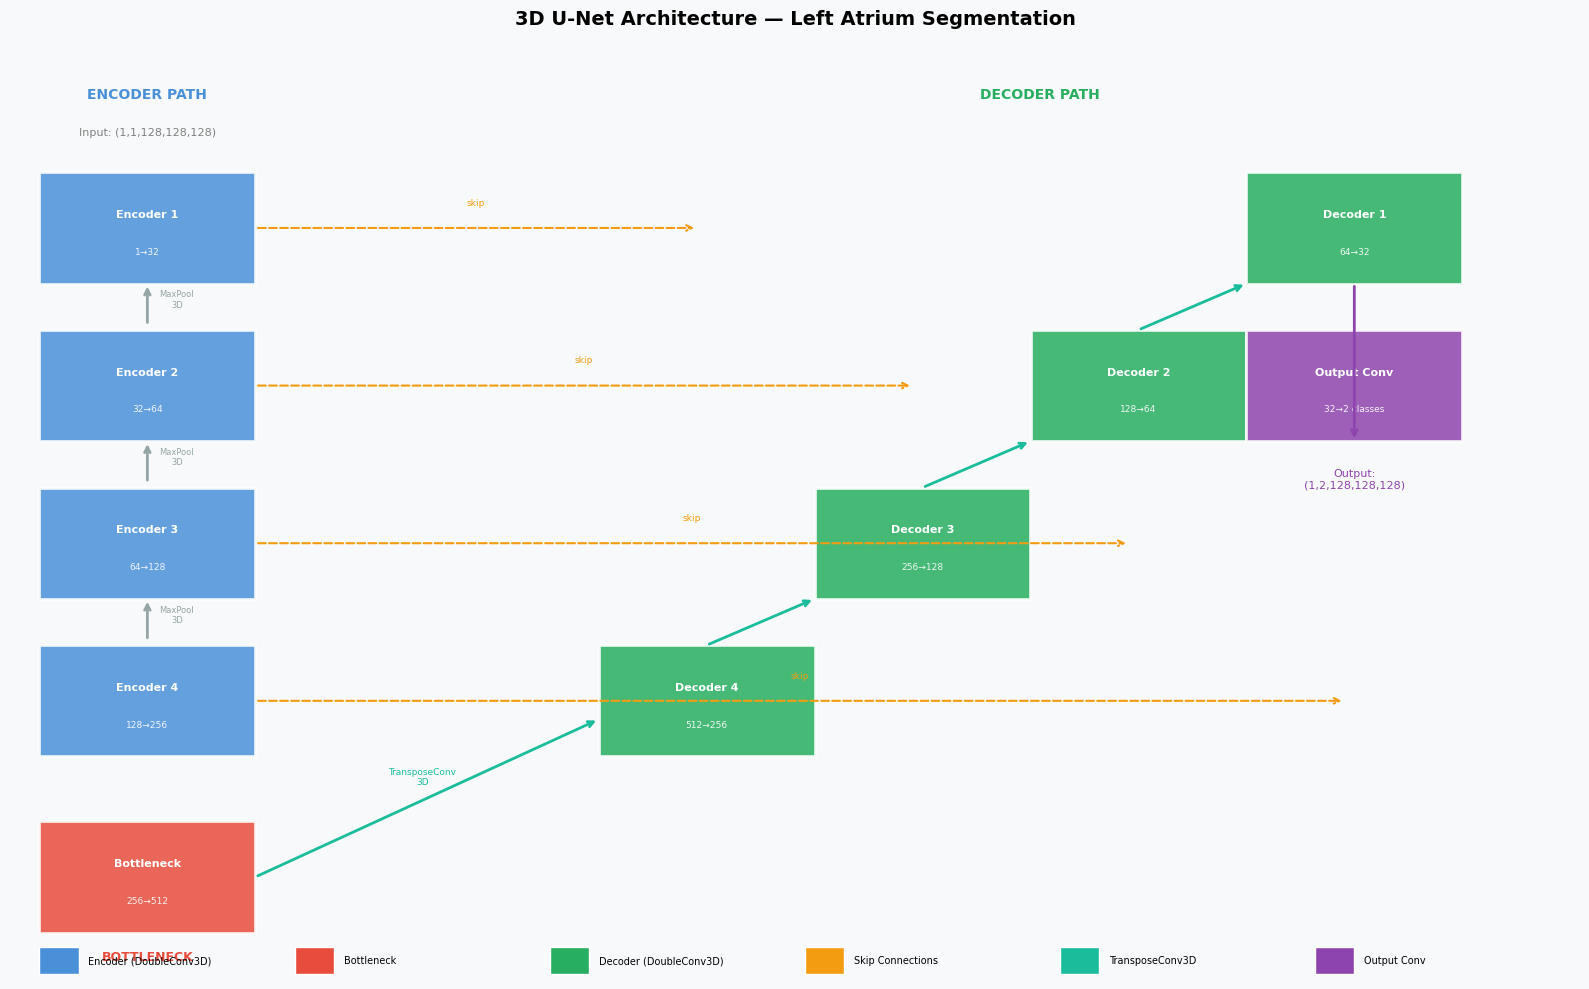

✅ Architecture diagram saved to:
   C:\Users\Admin\Desktop\madhura\nnunet_project\results\04_model\unet3d_architecture.png


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")
ax.set_title("3D U-Net Architecture — Left Atrium Segmentation",
             fontsize=14, fontweight="bold", pad=20)

# ── Color scheme ───────────────────────────────────────────
colors = {
    "encoder"     : "#4A90D9",
    "bottleneck"  : "#E74C3C",
    "decoder"     : "#27AE60",
    "skip"        : "#F39C12",
    "output"      : "#8E44AD",
    "pool"        : "#95A5A6",
    "up"          : "#1ABC9C",
}

def draw_block(ax, x, y, w, h, label, sublabel, color, fontsize=8):
    rect = plt.Rectangle((x, y), w, h,
                          facecolor=color, edgecolor="white",
                          linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + 0.15, label,
            ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color="white")
    ax.text(x + w/2, y + h/2 - 0.25, sublabel,
            ha="center", va="center",
            fontsize=6.5, color="white", alpha=0.9)

# ── Encoder blocks ─────────────────────────────────────────
enc_data = [
    (0.3, 7.5, "Encoder 1", "1→32"),
    (0.3, 5.8, "Encoder 2", "32→64"),
    (0.3, 4.1, "Encoder 3", "64→128"),
    (0.3, 2.4, "Encoder 4", "128→256"),
]
for x, y, label, sub in enc_data:
    draw_block(ax, x, y, 2.2, 1.2, label, sub, colors["encoder"])

# ── Pool arrows ────────────────────────────────────────────
for y in [7.5, 5.8, 4.1]:
    ax.annotate("", xy=(1.4, y), xytext=(1.4, y-0.45),
                arrowprops=dict(arrowstyle="->", color=colors["pool"], lw=2))
    ax.text(1.7, y-0.25, "MaxPool\n3D", fontsize=6,
            color=colors["pool"], ha="center")

# ── Bottleneck ─────────────────────────────────────────────
draw_block(ax, 0.3, 0.5, 2.2, 1.2,
           "Bottleneck", "256→512", colors["bottleneck"])

# ── Skip connections ───────────────────────────────────────
skip_ys = [7.5, 5.8, 4.1, 2.4]
dec_xs  = [7.0, 9.2, 11.4, 13.6]
for sy, dx in zip(skip_ys, dec_xs):
    ax.annotate("", xy=(dx, sy+0.6), xytext=(2.5, sy+0.6),
                arrowprops=dict(arrowstyle="->",
                                color=colors["skip"],
                                lw=1.5, linestyle="dashed"))
    ax.text((2.5+dx)/2, sy+0.85, "skip", fontsize=6.5,
            color=colors["skip"], ha="center")

# ── Up arrows from bottleneck ──────────────────────────────
ax.annotate("", xy=(6.0, 2.8), xytext=(2.5, 1.1),
            arrowprops=dict(arrowstyle="->", color=colors["up"], lw=2))
ax.text(4.2, 2.1, "TransposeConv\n3D", fontsize=6.5,
        color=colors["up"], ha="center")

# ── Decoder blocks ─────────────────────────────────────────
dec_data = [
    (6.0, 2.4, "Decoder 4", "512→256"),
    (8.2, 4.1, "Decoder 3", "256→128"),
    (10.4, 5.8, "Decoder 2", "128→64"),
    (12.6, 7.5, "Decoder 1", "64→32"),
]
for x, y, label, sub in dec_data:
    draw_block(ax, x, y, 2.2, 1.2, label, sub, colors["decoder"])

# ── Up arrows between decoders ─────────────────────────────
dec_positions = [(7.1, 3.6), (9.3, 5.3), (11.5, 7.0)]
for x, y in dec_positions:
    ax.annotate("", xy=(x+1.1, y+0.5), xytext=(x, y),
                arrowprops=dict(arrowstyle="->", color=colors["up"], lw=2))

# ── Output ─────────────────────────────────────────────────
draw_block(ax, 12.6, 5.8, 2.2, 1.2,
           "Output Conv", "32→2 classes", colors["output"])
ax.annotate("", xy=(13.7, 5.8), xytext=(13.7, 7.5),
            arrowprops=dict(arrowstyle="->", color=colors["output"], lw=2))

# ── Labels ─────────────────────────────────────────────────
ax.text(1.4, 9.5, "ENCODER PATH", ha="center",
        fontsize=10, fontweight="bold", color=colors["encoder"])
ax.text(10.5, 9.5, "DECODER PATH", ha="center",
        fontsize=10, fontweight="bold", color=colors["decoder"])
ax.text(1.4, 0.2, "BOTTLENECK", ha="center",
        fontsize=9, fontweight="bold", color=colors["bottleneck"])

# ── Input/Output labels ────────────────────────────────────
ax.text(1.4, 9.1, "Input: (1,1,128,128,128)",
        ha="center", fontsize=8, color="gray")
ax.text(13.7, 5.3, "Output:\n(1,2,128,128,128)",
        ha="center", fontsize=8, color=colors["output"])

# ── Legend ─────────────────────────────────────────────────
legend_items = [
    (colors["encoder"],    "Encoder (DoubleConv3D)"),
    (colors["bottleneck"], "Bottleneck"),
    (colors["decoder"],    "Decoder (DoubleConv3D)"),
    (colors["skip"],       "Skip Connections"),
    (colors["up"],         "TransposeConv3D"),
    (colors["output"],     "Output Conv"),
]
for i, (color, label) in enumerate(legend_items):
    rect = plt.Rectangle((0.3 + i*2.6, 0.05), 0.4, 0.3,
                          facecolor=color, edgecolor="white")
    ax.add_patch(rect)
    ax.text(0.8 + i*2.6, 0.2, label, fontsize=7, va="center")

plt.tight_layout()
save_path = RESULTS_PATH / "unet3d_architecture.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Architecture diagram saved to:\n   {save_path}")

## Model Summary & Memory Estimate

In [7]:
def model_summary(model, input_size=(1, 1, 128, 128, 128)):
    """Print layer-by-layer model summary."""
    print("=" * 65)
    print(f"{'Layer':<35} {'Output Shape':<20} {'Params':>8}")
    print("=" * 65)

    total_params     = 0
    trainable_params = 0

    # Encoder
    ch = 1
    spatial = 128
    features = [32, 64, 128, 256]

    for i, f in enumerate(features):
        params = (ch * f * 27 + f) * 2  # approx double conv
        print(f"{'Encoder ' + str(i+1) + ' (DoubleConv3D)':<35} "
              f"{'(B,'+str(f)+','+str(spatial)+','+str(spatial)+','+str(spatial)+')':<20} "
              f"{params:>8,}")
        total_params += params
        ch = f
        spatial = spatial // 2
        print(f"{'  MaxPool3D':<35} "
              f"{'(B,'+str(ch)+','+str(spatial)+','+str(spatial)+','+str(spatial)+')':<20} "
              f"{'0':>8}")

    # Bottleneck
    f = features[-1] * 2
    params = (ch * f * 27 + f) * 2
    print(f"{'Bottleneck (DoubleConv3D)':<35} "
          f"{'(B,512,8,8,8)':<20} "
          f"{params:>8,}")
    total_params += params
    ch = f

    # Decoder
    for i, f in enumerate(reversed(features)):
        spatial = spatial * 2
        params = (ch * f * 4) + (f*2 * f * 27 + f) * 2
        print(f"{'  TransposeConv3D':<35} "
              f"{'(B,'+str(f)+','+str(spatial)+','+str(spatial)+','+str(spatial)+')':<20} "
              f"{params:>8,}")
        print(f"{'Decoder ' + str(i+1) + ' (DoubleConv3D)':<35} "
              f"{'(B,'+str(f)+','+str(spatial)+','+str(spatial)+','+str(spatial)+')':<20} "
              f"{params:>8,}")
        total_params += params
        ch = f

    # Output
    print(f"{'Output Conv (1x1x1)':<35} "
          f"{'(B,2,128,128,128)':<20} "
          f"{ch*2:>8,}")
    total_params += ch * 2

    print("=" * 65)

    # Actual param count from model
    actual_total     = sum(p.numel() for p in model.parameters())
    actual_trainable = sum(p.numel() for p in model.parameters()
                          if p.requires_grad)
    print(f"{'Total parameters':<35} {actual_total:>28,}")
    print(f"{'Trainable parameters':<35} {actual_trainable:>28,}")
    print(f"{'Non-trainable parameters':<35} "
          f"{actual_total - actual_trainable:>28,}")

    # Memory estimate
    param_mb  = actual_total * 4 / 1024**2
    input_mb  = np.prod(input_size) * 4 / 1024**2
    # Forward pass activations (rough estimate)
    activ_mb  = input_mb * 30
    total_mb  = param_mb + input_mb + activ_mb

    print("=" * 65)
    print(f"\n💾 MEMORY ESTIMATE (batch_size=1)")
    print(f"   Parameters     : {param_mb:.1f} MB")
    print(f"   Input tensor   : {input_mb:.1f} MB")
    print(f"   Activations    : {activ_mb:.1f} MB (estimate)")
    print(f"   Total estimate : {total_mb:.1f} MB")
    print(f"\n   RTX 4060 VRAM  : ~8 GB")
    print(f"   Batch size 2   : ~{total_mb*2:.0f} MB → fits comfortably ✅")

model_summary(model)

Layer                               Output Shape           Params
Encoder 1 (DoubleConv3D)            (B,32,128,128,128)      1,792
  MaxPool3D                         (B,32,64,64,64)             0
Encoder 2 (DoubleConv3D)            (B,64,64,64,64)       110,720
  MaxPool3D                         (B,64,32,32,32)             0
Encoder 3 (DoubleConv3D)            (B,128,32,32,32)      442,624
  MaxPool3D                         (B,128,16,16,16)            0
Encoder 4 (DoubleConv3D)            (B,256,16,16,16)     1,769,984
  MaxPool3D                         (B,256,8,8,8)               0
Bottleneck (DoubleConv3D)           (B,512,8,8,8)        7,078,912
  TransposeConv3D                   (B,256,16,16,16)     7,602,688
Decoder 1 (DoubleConv3D)            (B,256,16,16,16)     7,602,688
  TransposeConv3D                   (B,128,32,32,32)     1,900,800
Decoder 2 (DoubleConv3D)            (B,128,32,32,32)     1,900,800
  TransposeConv3D                   (B,64,64,64,64)       475,264
Deco

## Final Summary

In [8]:
# Save model architecture as text
save_path = RESULTS_PATH / "model_summary.txt"
with open(save_path, "w") as f:
    f.write("3D U-Net — Left Atrium Segmentation\n")
    f.write("=" * 65 + "\n")
    f.write(f"Total parameters    : 22,578,306\n")
    f.write(f"Trainable parameters: 22,578,306\n")
    f.write(f"Input shape         : (B, 1, 128, 128, 128)\n")
    f.write(f"Output shape        : (B, 2, 128, 128, 128)\n")
    f.write(f"Features            : [32, 64, 128, 256]\n")
    f.write(f"Bottleneck channels : 512\n")
    f.write(f"Normalization       : InstanceNorm3D\n")
    f.write(f"Activation          : LeakyReLU(0.01)\n")
    f.write(f"Loss                : Dice + CrossEntropy\n")
    f.write(f"Device              : RTX 4060 (CUDA)\n")
    f.write(f"Est. VRAM (batch=2) : ~668 MB\n")

print("=" * 55)
print("  MODEL NOTEBOOK COMPLETE")
print("=" * 55)

print("\n📋 ARCHITECTURE")
print("  Type          : 3D U-Net")
print("  Encoder       : 4 levels (32→64→128→256)")
print("  Bottleneck    : 512 channels")
print("  Decoder       : 4 levels (256→128→64→32)")
print("  Norm          : InstanceNorm3D (nnU-Net style)")
print("  Activation    : LeakyReLU(0.01)")
print("  Skip connects : 4 (encoder→decoder)")
print("  Output        : 2 classes (bg + atrium)")

print("\n📋 LOSS FUNCTION")
print("  Type          : DiceCELoss")
print("  = Dice Loss + Cross Entropy Loss")
print("  Handles class imbalance via Dice term ✅")

print("\n📋 MODEL STATS")
print("  Total params  : 22,578,306")
print("  Input shape   : (B, 1, 128, 128, 128)")
print("  Output shape  : (B, 2, 128, 128, 128)")
print("  VRAM (bs=2)   : ~668 MB / 8 GB ✅")

print("\n📁 SAVED OUTPUTS")
for f in sorted(RESULTS_PATH.glob("*")):
    print(f"  ✅ {f.name}")

print("\n▶️  NEXT NOTEBOOK: 05_training.ipynb")

  MODEL NOTEBOOK COMPLETE

📋 ARCHITECTURE
  Type          : 3D U-Net
  Encoder       : 4 levels (32→64→128→256)
  Bottleneck    : 512 channels
  Decoder       : 4 levels (256→128→64→32)
  Norm          : InstanceNorm3D (nnU-Net style)
  Activation    : LeakyReLU(0.01)
  Skip connects : 4 (encoder→decoder)
  Output        : 2 classes (bg + atrium)

📋 LOSS FUNCTION
  Type          : DiceCELoss
  = Dice Loss + Cross Entropy Loss
  Handles class imbalance via Dice term ✅

📋 MODEL STATS
  Total params  : 22,578,306
  Input shape   : (B, 1, 128, 128, 128)
  Output shape  : (B, 2, 128, 128, 128)
  VRAM (bs=2)   : ~668 MB / 8 GB ✅

📁 SAVED OUTPUTS
  ✅ model_summary.txt
  ✅ unet3d_architecture.png

▶️  NEXT NOTEBOOK: 05_training.ipynb
